In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fear = pd.read_csv("data/fear_greed_index.csv")
historical = pd.read_csv("data/historical_data.csv")

print("Historical missing values")
print(historical.isnull().sum())

print("\nFear missing values")
print(fear.isnull().sum())

print(historical.info())
print(fear.info())

fear.columns = fear.columns.str.strip()
historical.columns = historical.columns.str.strip()

print(fear.columns)
print(historical.columns)
print("Historical Columns")
print(historical.head())
print("Fear Columns")
print(fear.head())

Historical missing values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Fear missing values
timestamp         0
value             0
classification    0
date              0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 


In [15]:
fear['date'] = pd.to_datetime(fear['date'])
historical['Timestamp IST'] = pd.to_datetime(
    historical['Timestamp IST'],
    format="%d-%m-%Y %H:%M",
    errors='coerce'
)

historical['date'] = historical['Timestamp IST'].dt.date
fear['date'] = fear['date'].dt.date

print(historical[['Timestamp IST','date']].head())
print(fear[['date']].head())

merged = pd.merge(
    historical,
    fear,
    on="date",
    how="inner"
)

print(merged.shape)
print(merged.head())

        Timestamp IST        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
         date
0  2018-02-01
1  2018-02-02
2  2018-02-03
3  2018-02-04
4  2018-02-05
(211218, 20)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


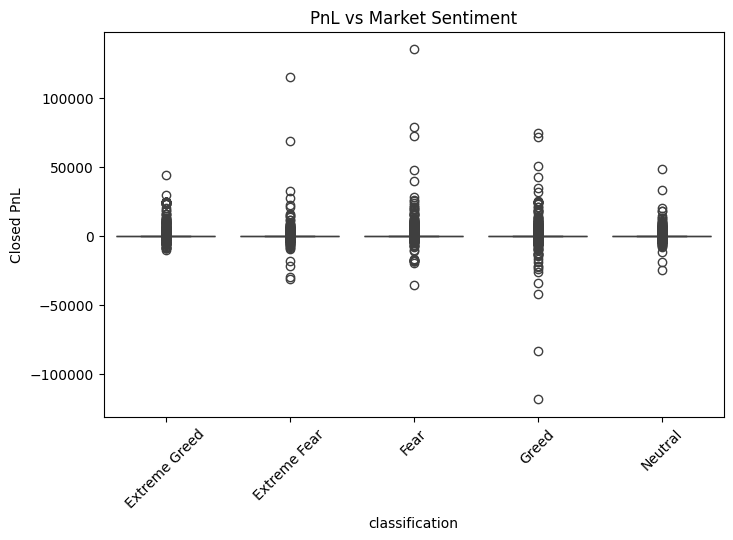

In [16]:
print(merged.groupby("classification")["Closed PnL"].mean())
print(merged["classification"].value_counts())

plt.figure(figsize=(8,5))

sns.boxplot(
    x="classification",
    y="Closed PnL",
    data=merged
)

plt.title("PnL vs Market Sentiment")
plt.xticks(rotation=45)
plt.show()

In [17]:
merged["profit"] = merged["Closed PnL"] > 0

print(merged.groupby("classification")["profit"].mean())

print(merged.groupby("classification")["Closed PnL"].sum())

print(merged.groupby("classification")["Closed PnL"].mean())

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: profit, dtype: float64
classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64
classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: './images/winrate_vs_sentiment.png'

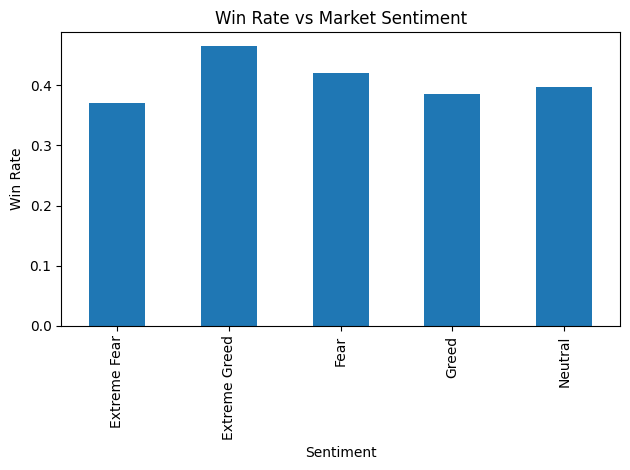

In [18]:
winrate = merged.groupby("classification")["profit"].mean()

winrate.plot(kind="bar")

plt.title("Win Rate vs Market Sentiment")

plt.xlabel("Sentiment")
plt.ylabel("Win Rate")

plt.tight_layout()

plt.savefig("./images/winrate_vs_sentiment.png")

plt.show()

In [ ]:
profit_vs_index = merged.groupby("value")["Closed PnL"].mean()
print(profit_vs_index.head())


plt.figure()
sns.scatterplot(x="value", y="Closed PnL", data=merged)
plt.title("Profit vs Fear & Greed Index Value")
plt.xlabel("Fear & Greed Index Value")
plt.ylabel("Closed PnL")
plt.show()

In [ ]:
merged["Side"].value_counts()
merged["Direction"].value_counts()

merged.groupby("Side")["Closed PnL"].mean()

merged.groupby("Side")["Closed PnL"].mean().plot(kind="bar")
plt.title("Average Profit by Side")
plt.ylabel("Average PnL")
plt.show()

In [ ]:
merged["profit"] = merged["Closed PnL"] > 0

merged.groupby("Direction")["profit"].mean() * 100

win_dir = merged.groupby("Direction")["profit"].mean() * 100

win_dir.plot(kind="bar")
plt.title("Win Rate by Direction")
plt.ylabel("Win %")
plt.show()